# Module 06: Multi-Component Mass Models

## Learning to Autolens

---

**Purpose:** Learn how to decompose a lens galaxy's mass into its physical components —
stellar mass (traced by light) and dark matter (NFW halo) — and understand what strong
lensing tells us about the internal structure of galaxies.

**Prerequisites:**
- Module 01 (mass profiles: SIE, NFW)
- Module 04 (SLaM pipeline — the MASS stage can use composite models)

**Key references:**
- Congdon & Keeton (2018), Ch. 4: Mass Models (hereafter **C&K**)
- Meneghetti (2021), Ch. 5: Lens Models
- Treu & Koopmans (2004), ApJ, 611, 739 — *Bulge-halo conspiracy*
- Nightingale et al. (2019), MNRAS, 489, 2049 — *Decomposed mass models with AutoLens*

**Companion LaTeX notes:** `../../Notes/06_MultiMass/06_multi_mass_theory.tex`

---

## Table of Contents

1. [Why Decompose the Mass?](#1-why-decompose)
2. [The Stellar Mass Component: Light Traces Mass](#2-stellar-mass)
3. [The Dark Matter Component: NFW Profile](#3-dark-matter)
4. [Composite Model: Stellar + Dark Matter + Shear](#4-composite-model)
5. [The Bulge-Halo Conspiracy](#5-bulge-halo-conspiracy)
6. [Fitting a Composite Model with PyAutoLens](#6-fitting-composite)
7. [Scaling Relations and Mass-to-Light Ratio](#7-scaling-relations)
8. [Exercises](#8-exercises)

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import autolens as al
import autolens.plot as aplt
import autofit as af

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.2.26.4


---

## 1. Why Decompose the Mass? <a id="1-why-decompose"></a>

### Total vs. Decomposed Mass Models

In Modules 03–05, we modeled the lens mass with a **total** profile (SIE or PowerLaw)
that describes the combined effect of all matter — stars, gas, and dark matter.
This is sufficient for measuring the Einstein radius and total enclosed mass.

But to understand **galaxy structure**, we need to decompose the mass:

| Component | Profile | Physical origin | What it tells us |
|-----------|---------|-----------------|------------------|
| Stellar mass | Sérsic (from light × M/L) | Stars, stellar remnants | Star formation history |
| Dark matter | NFW | Cosmological halo | Halo mass, concentration |
| External shear | Shear | Tidal field from environment | Group/cluster membership |

### The Key Question

Strong lensing measures the **total projected mass** within $\theta_E$.
The decomposition asks: how much of that mass is stars vs. dark matter?
This constrains the **dark matter fraction** $f_{\rm DM}$ within the
Einstein radius — a powerful probe of galaxy formation.

---

## 2. The Stellar Mass Component: Light Traces Mass <a id="2-stellar-mass"></a>

### Theory: Mass-to-Light Ratio

The stellar mass distribution follows the light distribution, scaled by
the **stellar mass-to-light ratio** $\Upsilon_*$:

$$
\Sigma_*(\boldsymbol{\theta}) = \Upsilon_* \cdot I(\boldsymbol{\theta})
$$

where $I(\boldsymbol{\theta})$ is the surface brightness and $\Upsilon_*$ has
units of $M_\odot / L_\odot$. For elliptical galaxies, $\Upsilon_* \sim 2$–$8$
$M_\odot / L_\odot$ depending on age, metallicity, and IMF.

In PyAutoLens, this is implemented by using the **same Sérsic profile** for
both light and mass, with $\Upsilon_*$ (`mass_to_light_ratio`) as a free parameter.

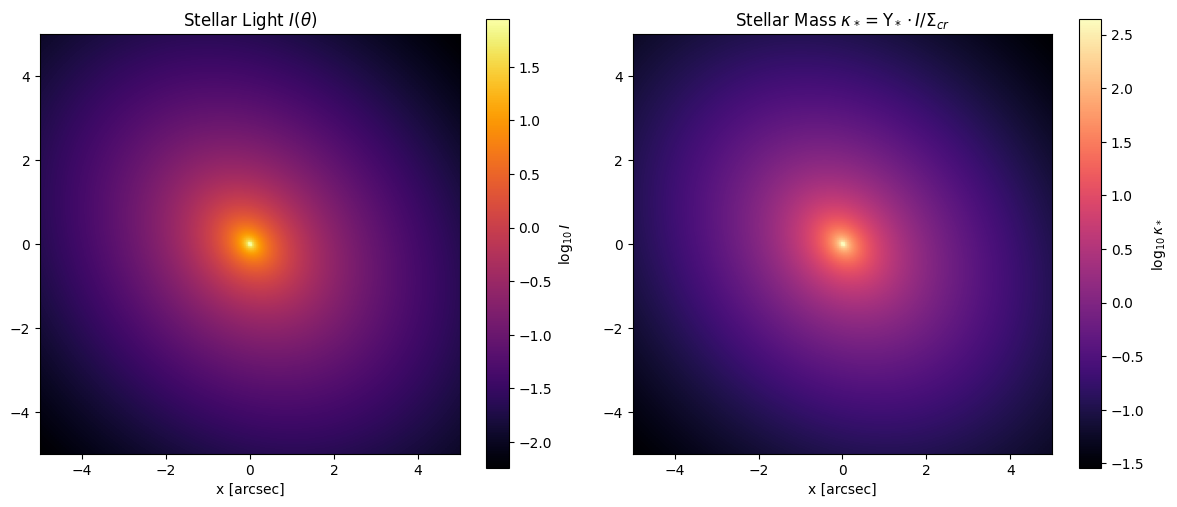

The stellar mass exactly traces the light — same shape, different normalization.


In [2]:
# ============================================================
# STELLAR MASS PROFILE: SÉRSIC WITH MASS-TO-LIGHT RATIO
# ============================================================
# al.lmp.Sersic is a "light-and-mass" profile: it produces
# both a light image AND a convergence map, with the mass
# distribution being the light × mass_to_light_ratio.
#
# This enforces the physical constraint that stellar mass
# traces the observed light.
# ============================================================

grid = al.Grid2D.uniform(shape_native=(200, 200), pixel_scales=0.05)

# Stellar mass component: light profile that also acts as mass
# TODO: try different mass_to_light_ratio values (2, 5, 8) to see
# how the stellar contribution to κ changes.
stellar_mass = al.lmp.Sersic(
    centre=(0.0, 0.0),
    ell_comps=al.convert.ell_comps_from(axis_ratio=0.8, angle=45.0),
    intensity=1.0,
    effective_radius=1.0,          # R_e = 1" (typical elliptical)
    sersic_index=4.0,              # de Vaucouleurs
    mass_to_light_ratio=5.0,       # Υ* = 5 M_sun/L_sun
)

# The convergence from stars alone
kappa_stars = stellar_mass.convergence_2d_from(grid=grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Light
image_stars = stellar_mass.image_2d_from(grid=grid)
im0 = axes[0].imshow(np.log10(image_stars.native + 1e-6), origin="lower",
                      cmap="inferno", extent=[-5, 5, -5, 5])
axes[0].set_title(r"Stellar Light $I(\theta)$")
axes[0].set_xlabel("x [arcsec]")
plt.colorbar(im0, ax=axes[0], label=r"$\log_{10} I$")

# Mass (convergence)
im1 = axes[1].imshow(np.log10(kappa_stars.native + 1e-6), origin="lower",
                      cmap="magma", extent=[-5, 5, -5, 5])
axes[1].set_title(r"Stellar Mass $\kappa_* = \Upsilon_* \cdot I / \Sigma_{cr}$")
axes[1].set_xlabel("x [arcsec]")
plt.colorbar(im1, ax=axes[1], label=r"$\log_{10} \kappa_*$")

plt.tight_layout()
plt.show()

print("The stellar mass exactly traces the light — same shape, different normalization.")

---

## 3. The Dark Matter Component: NFW Profile <a id="3-dark-matter"></a>

### Theory: The NFW Halo

Cosmological N-body simulations show that dark matter halos follow the
**NFW profile** (Navarro, Frenk & White 1996):

$$
\rho(r) = \frac{\rho_s}{(r/r_s)(1 + r/r_s)^2}
$$

where $r_s$ is the scale radius and $\rho_s$ is the characteristic density.
The halo is characterized by its virial mass $M_{200}$ and **concentration**
$c = r_{200}/r_s$, which are correlated: more massive halos are less concentrated.

For lensing, the projected (2D) convergence has an analytic form
(Bartelmann 1996; C&K Sec. 4.5).

### Key difference from stellar mass

The NFW profile is much more **extended** than the stellar component:
- Stellar: concentrated within $\sim$ few $R_e$ ($\sim$ few kpc)
- NFW: extends to $r_{200} \sim 200$–$500$ kpc

Within the Einstein radius, the NFW contribution is relatively **flat**
(the cuspy center of NFW is less steep than Sérsic n=4).

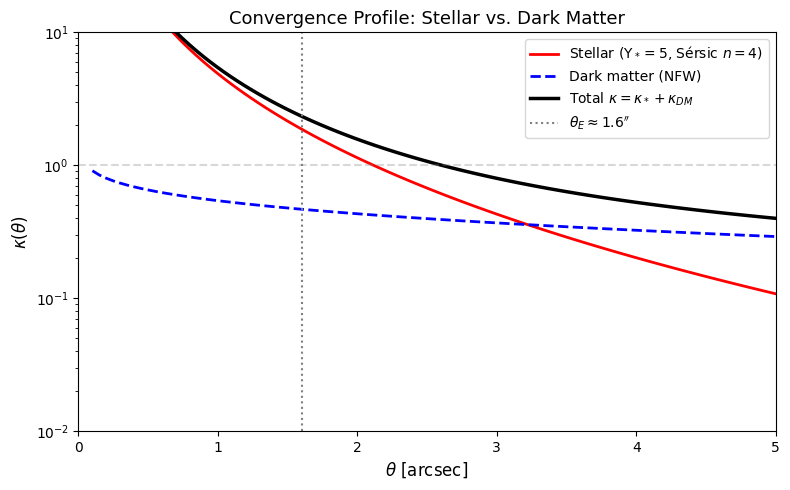

Stars dominate the center; dark matter dominates the outskirts.
At the Einstein radius, both contribute — this is the bulge-halo conspiracy.


In [3]:
# ============================================================
# NFW DARK MATTER HALO
# ============================================================
# In PyAutoLens, the NFW profile is parameterized by:
#   kappa_s: characteristic convergence (dimensionless)
#   scale_radius: r_s in arc-seconds
#
# Typical values for a galaxy-mass halo at z~0.5:
#   M_200 ~ 10^13 M_sun → r_s ~ 30-50", kappa_s ~ 0.05-0.15
# ============================================================

nfw_halo = al.mp.NFWSph(
    centre=(0.0, 0.0),
    kappa_s=0.08,              # Characteristic convergence
    scale_radius=40.0,         # r_s = 40" (very extended!)
)

kappa_dm = nfw_halo.convergence_2d_from(grid=grid)

# Compare radial profiles: stellar vs. dark matter
r = np.linspace(0.1, 5.0, 100)
# Sample along x-axis
grid_1d = al.Grid2DIrregular(
    values=[(0.0, ri) for ri in r]
)

kappa_stars_1d = stellar_mass.convergence_2d_from(grid=grid_1d)
kappa_dm_1d = nfw_halo.convergence_2d_from(grid=grid_1d)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(r, kappa_stars_1d, 'r-', lw=2, label=r"Stellar ($\Upsilon_* = 5$, Sérsic $n=4$)")
ax.semilogy(r, kappa_dm_1d, 'b--', lw=2, label=r"Dark matter (NFW)")
ax.semilogy(r, np.array(kappa_stars_1d) + np.array(kappa_dm_1d), 'k-', lw=2.5,
            label=r"Total $\kappa = \kappa_* + \kappa_{DM}$")
ax.axvline(1.6, color='gray', ls=':', label=r"$\theta_E \approx 1.6''$")
ax.axhline(1.0, color='gray', ls='--', alpha=0.3)
ax.set_xlabel(r"$\theta$ [arcsec]", fontsize=12)
ax.set_ylabel(r"$\kappa(\theta)$", fontsize=12)
ax.set_title("Convergence Profile: Stellar vs. Dark Matter", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0.01, 10)
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

print("Stars dominate the center; dark matter dominates the outskirts.")
print("At the Einstein radius, both contribute — this is the bulge-halo conspiracy.")

---

## 4. Composite Model: Stellar + Dark Matter + Shear <a id="4-composite-model"></a>

### Building a Composite Lens Galaxy

In PyAutoLens, a composite model is simply a Galaxy with multiple mass components.
The total deflection is the **sum** of individual deflections (superposition
principle in the weak-field limit):

$$
\boldsymbol{\alpha}_{\rm total} = \boldsymbol{\alpha}_*(\boldsymbol{\theta})
+ \boldsymbol{\alpha}_{\rm DM}(\boldsymbol{\theta})
+ \boldsymbol{\alpha}_{\rm shear}(\boldsymbol{\theta})
$$

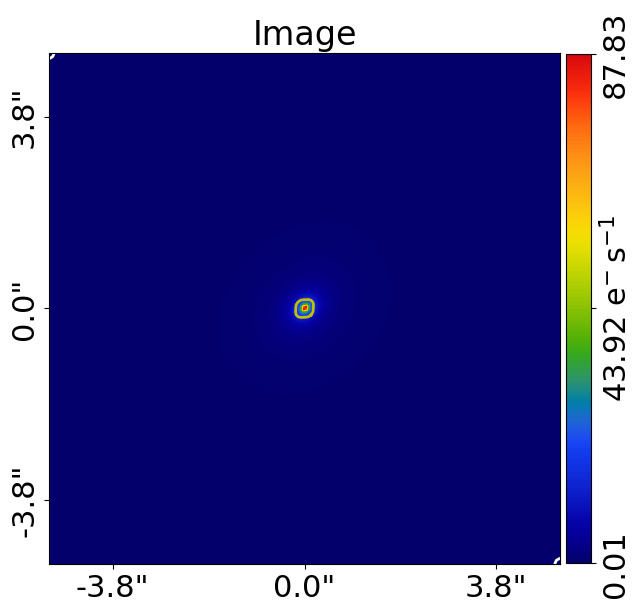

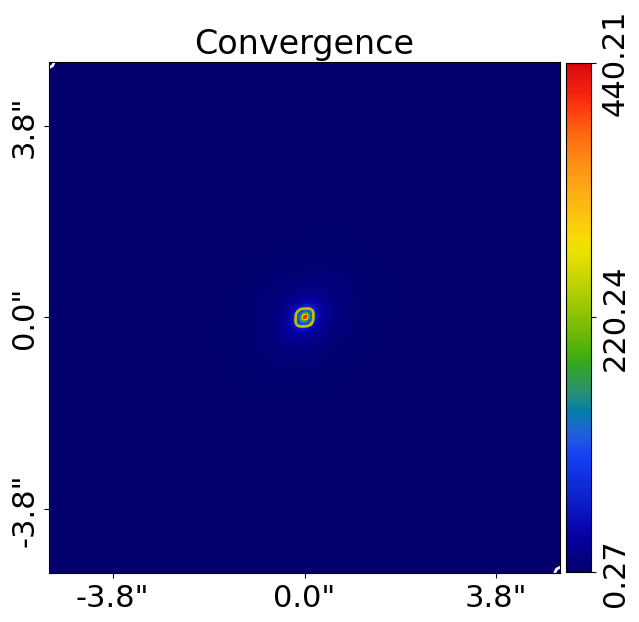

In [4]:
# ============================================================
# COMPOSITE LENS GALAXY
# ============================================================
# Three mass components on one Galaxy object:
#   1. stellar_mass (lmp.Sersic): light traces mass
#   2. dark_matter (mp.NFWSph): dark matter halo
#   3. shear (mp.ExternalShear): tidal environment
#
# Note: 'stellar_mass' is an lmp profile (light+mass),
# so it contributes both light AND mass to the Galaxy.
# ============================================================

lens_composite = al.Galaxy(
    redshift=0.5,
    stellar_mass=al.lmp.Sersic(
        centre=(0.0, 0.0),
        ell_comps=al.convert.ell_comps_from(axis_ratio=0.8, angle=45.0),
        intensity=1.0,
        effective_radius=1.0,
        sersic_index=4.0,
        mass_to_light_ratio=5.0,
    ),
    dark_matter=al.mp.NFWSph(
        centre=(0.0, 0.0),
        kappa_s=0.08,
        scale_radius=40.0,
    ),
    shear=al.mp.ExternalShear(gamma_1=0.05, gamma_2=0.02),
)

source_galaxy = al.Galaxy(
    redshift=1.0,
    bulge=al.lp.SersicCore(
        centre=(0.1, 0.05),
        ell_comps=(0.15, 0.1),
        intensity=0.5,
        effective_radius=0.3,
        sersic_index=1.0,
    ),
)

tracer_composite = al.Tracer(galaxies=[lens_composite, source_galaxy])

# Visualize
tracer_plotter = aplt.TracerPlotter(tracer=tracer_composite, grid=grid)
tracer_plotter.figures_2d(image=True, convergence=True)

---

## 5. The Bulge-Halo Conspiracy <a id="5-bulge-halo-conspiracy"></a>

### Theory

Observations show that the **total** density profile of massive ellipticals
is remarkably close to isothermal ($\rho_{\rm tot} \propto r^{-2}$, i.e.,
power-law slope $\gamma' \approx 2$), even though neither the stellar nor
dark matter component is isothermal individually:

- Stellar: steeper than isothermal in the center (Sérsic n=4, $\rho_* \propto r^{-3}$ at small $r$)
- Dark matter: shallower than isothermal ($\rho_{\rm DM} \propto r^{-1}$ for NFW)

The two components **conspire** to produce a nearly isothermal total profile.
This is the **bulge-halo conspiracy** (Treu & Koopmans 2004; Koopmans et al. 2006).

Lensing + kinematics data constrain this decomposition: lensing gives the
total mass at $\theta_E$, while velocity dispersions constrain the mass profile
slope, helping to disentangle the stellar and dark components.

---

## 6. Fitting a Composite Model with PyAutoLens <a id="6-fitting-composite"></a>

### Model Setup

A composite model has more free parameters than a total mass model:
- Stellar: shared with light profile + $\Upsilon_*$ (1 extra param)
- NFW: centre (2), $\kappa_s$ (1), $r_s$ (1) = 4 params
- Shear: $\gamma_1$ (1), $\gamma_2$ (1) = 2 params

This is best done in the SLaM MASS stage, replacing `al.mp.Isothermal`
with the composite model.

In [5]:
# ============================================================
# COMPOSITE MODEL SETUP FOR FITTING
# ============================================================
# In practice, you'd run this as the MASS TOTAL stage of SLaM,
# with light and source already determined.
#
# Key: the stellar_mass profile shares its structural parameters
# (centre, ell_comps, R_e, n) with the light profile — only
# mass_to_light_ratio is additional.
#
# TODO: Tie the stellar mass centre to the NFW centre
# (physical expectation: stars sit at halo center).
# ============================================================

# Load example dataset
dataset_path = Path(
    "../autolens_workspace_original/dataset/imaging/simple__no_lens_light"
)
dataset = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits",
    psf_path=dataset_path / "psf.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    pixel_scales=0.1,
)
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=3.0,
)
dataset = dataset.apply_mask(mask=mask)

# Composite lens model
lens_model = af.Model(
    al.Galaxy,
    redshift=0.5,
    stellar_mass=al.lmp.Sersic,        # Light+mass profile
    dark_matter=al.mp.NFWSph,           # Dark matter halo
    shear=al.mp.ExternalShear,
)

# Tie the NFW centre to the stellar mass centre
# (physically motivated: stars form at the halo center)
lens_model.dark_matter.centre = lens_model.stellar_mass.centre

source_model = af.Model(
    al.Galaxy,
    redshift=1.0,
    bulge=al.lp.SersicCore,
)

model = af.Collection(
    galaxies=af.Collection(lens=lens_model, source=source_model)
)

print(f"Total free parameters: {model.total_free_parameters}")
print("\nModel info:")
print(model.info)

2026-04-17 17:28:06,042 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 2828 image-pixels


Total free parameters: 19

Model info:
Total Free Parameters = 19

model                                                                           Collection (N=19)
    galaxies                                                                    Collection (N=19)
        lens                                                                    Galaxy (N=12)
            stellar_mass                                                        Sersic (N=8)
            dark_matter                                                         NFWSph (N=4)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=7)
            bulge                                                               SersicCore (N=7)

galaxies
    lens
        redshift                                                                0.5
        dark_matter - stellar_mass
            centre
          

2026-04-17 17:28:06,388 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.


2026-04-17 17:28:06,682 - composite_mass - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/Learning_to_Autolens/Solutions/output/output/module_06/composite_mass/f02e338f72119206914e5e7a54502952


2026-04-17 17:28:06,683 - composite_mass - INFO - Outputting pre-fit files (e.g. model.info, visualization).


2026-04-17 17:28:07,233 - composite_mass - INFO - Starting new Nautilus non-linear search (no previous samples found).


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


...

2026-04-17 17:59:02,203 - composite_mass - INFO - Removing search internal folder.


2026-04-17 17:59:02,204 - composite_mass - INFO - Removing all files except for .zip file


2026-04-17 17:59:02,460 - composite_mass - INFO - Search complete, returning result



Fit complete!


Bayesian Evidence                                                               5838.63138628
Maximum Log Likelihood                                                          5949.26557804

model                                                                           Collection (N=19)
    galaxies                                                                    Collection (N=19)
        lens                                                                    Galaxy (N=12)
            stellar_mass                                                        Sersic (N=8)
            dark_matter                                                         NFWSph (N=4)
            shear                                                               ExternalShear (N=2)
        source                                                                  Galaxy (N=7)
            bulge                                                               SersicCore (N=7)

Maximum Log Likelihood Model:

galaxies
    

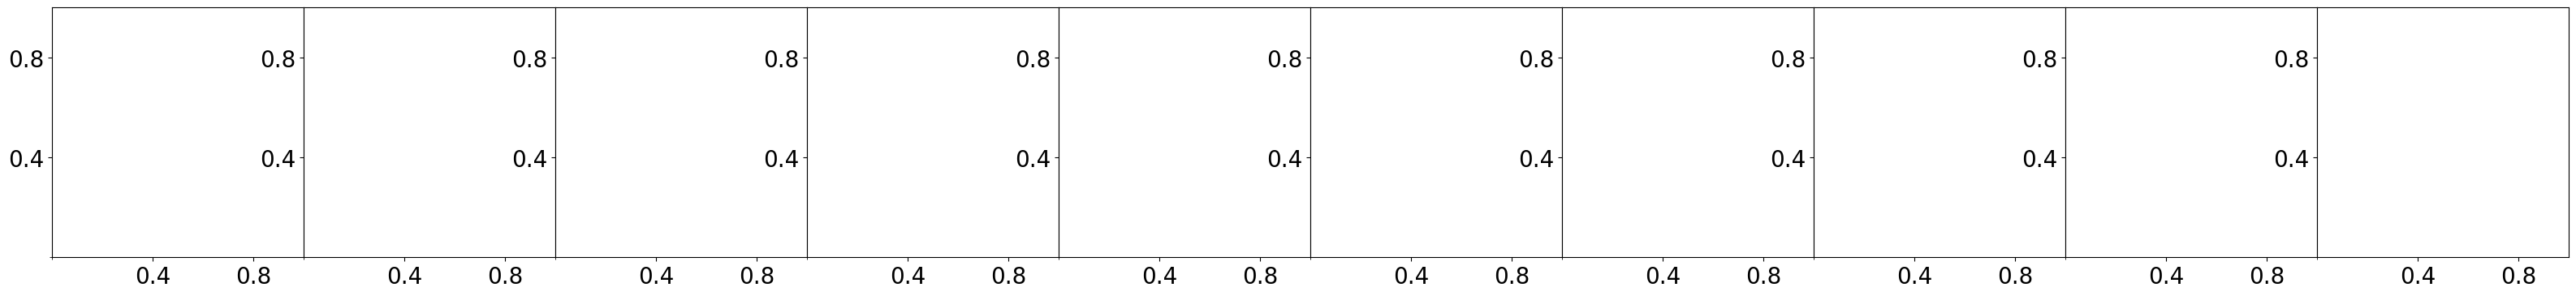

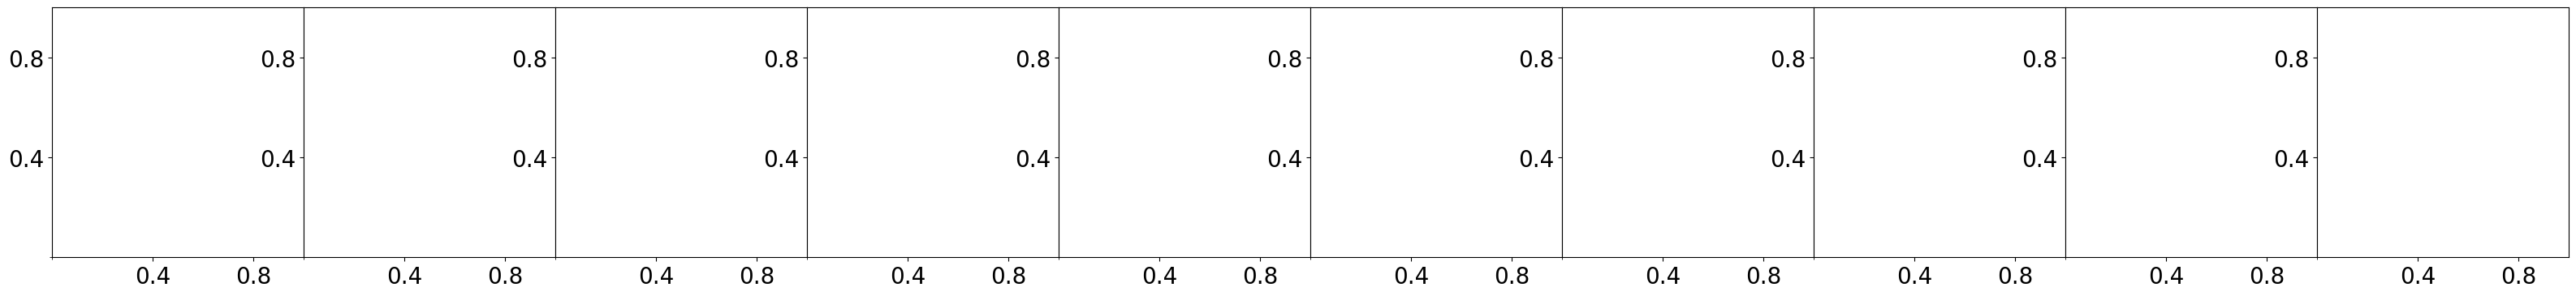

In [6]:
# ============================================================
# RUN THE FIT
# ============================================================
# This is a demonstration — in practice, use the SLaM pipeline
# to initialize the light profile before fitting the composite
# mass model.
# ============================================================

search = af.Nautilus(
    path_prefix=Path("output") / "module_06",
    name="composite_mass",
    n_live=100,
)

analysis = al.AnalysisImaging(dataset=dataset, use_jax=False)

result_composite = search.fit(model=model, analysis=analysis)

print("\nFit complete!")
print(result_composite.info)


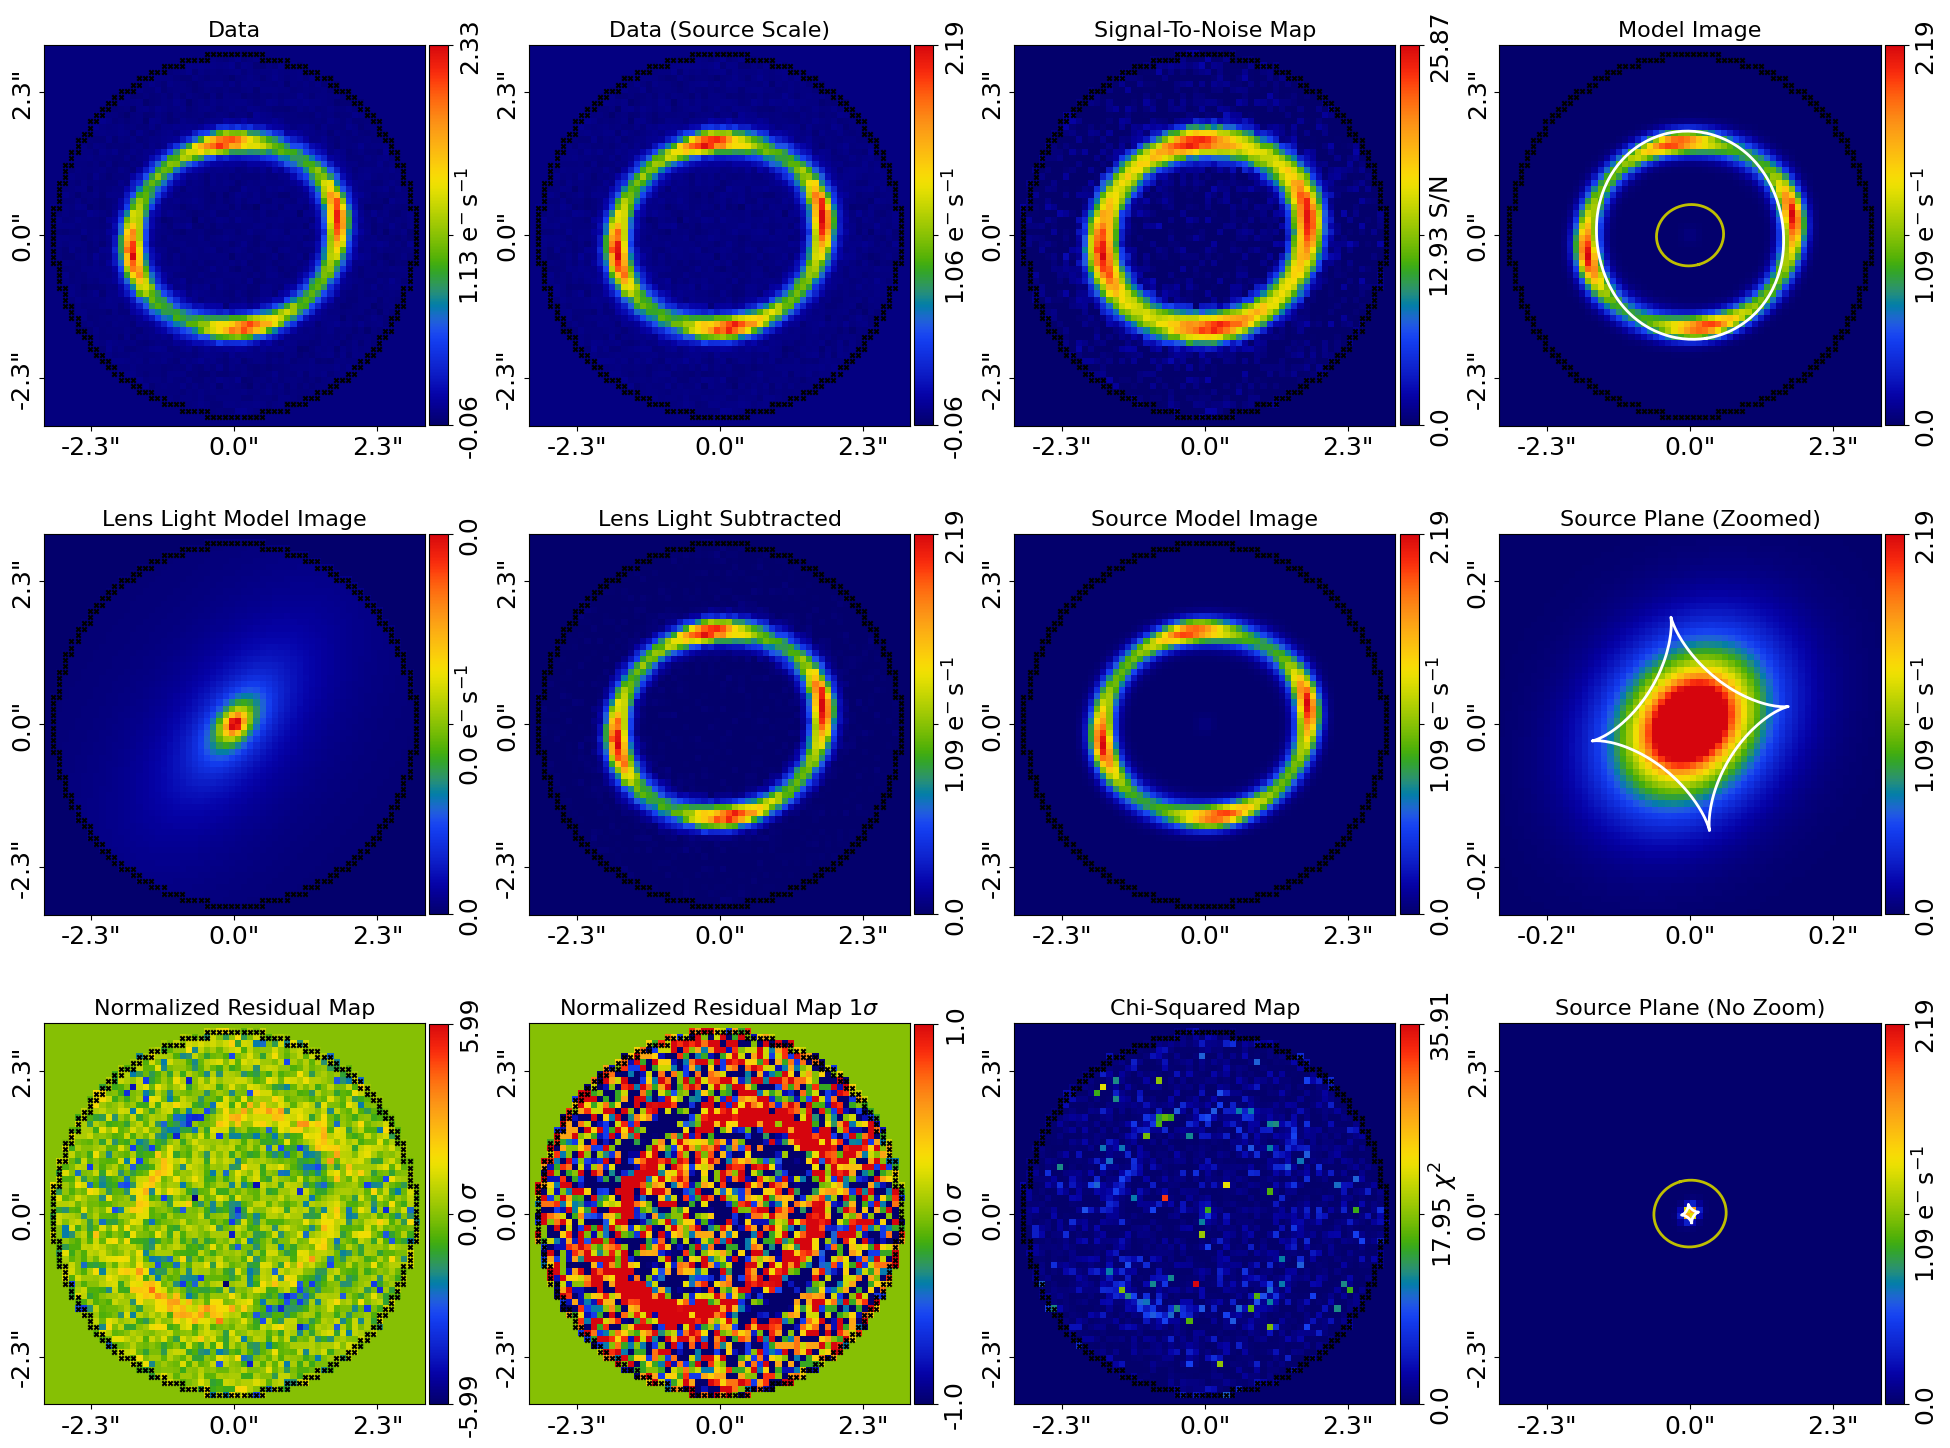


Best-fit mass-to-light ratio: Υ* = 155.59
Best-fit NFW κ_s = 0.5672
Best-fit NFW r_s = 2.4 arcsec


In [7]:
# ============================================================
# DARK MATTER FRACTION
# ============================================================
# Compute the dark matter fraction within the Einstein radius:
#   f_DM = M_DM(<θ_E) / M_total(<θ_E)
# ============================================================

fit_plotter = aplt.FitImagingPlotter(fit=result_composite.max_log_likelihood_fit)
fit_plotter.subplot_fit()

# TODO: Extract κ_stars and κ_DM at the Einstein radius
# to compute f_DM. This requires accessing the individual
# mass profile components from the best-fit instance.
ml = result_composite.max_log_likelihood_instance
print(f"\nBest-fit mass-to-light ratio: Υ* = {ml.galaxies.lens.stellar_mass.mass_to_light_ratio:.2f}")
print(f"Best-fit NFW κ_s = {ml.galaxies.lens.dark_matter.kappa_s:.4f}")
print(f"Best-fit NFW r_s = {ml.galaxies.lens.dark_matter.scale_radius:.1f} arcsec")

---

## 7. Scaling Relations and Mass-to-Light Ratio <a id="7-scaling-relations"></a>

### Connecting Lensing to Galaxy Physics

The mass-to-light ratio $\Upsilon_*$ from lens modeling can be compared with
independent estimates from **stellar population synthesis** (SPS) models.
Systematic differences indicate:
- $\Upsilon_{*,\rm lens} > \Upsilon_{*,\rm SPS}$: the lens model attributes too
  much mass to stars (perhaps the NFW is wrong, or there's adiabatic contraction)
- $\Upsilon_{*,\rm lens} < \Upsilon_{*,\rm SPS}$: the stellar IMF assumed in SPS
  overestimates the true stellar mass (IMF variation)

This is a major application of decomposed lens models: constraining the
**stellar initial mass function** (IMF) in massive ellipticals.

### The Fundamental Plane

Lens galaxies lie on the **Fundamental Plane** relating effective radius,
velocity dispersion, and surface brightness. The tilt of the FP from the
virial prediction is related to variations in $\Upsilon_*$ and dark matter
fraction with galaxy mass.

---

## 8. Exercises <a id="8-exercises"></a>

### Exercise 1: Dark Matter Fraction

For the composite model, compute the dark matter fraction within the Einstein
radius: evaluate $\kappa_*$ and $\kappa_{\rm DM}$ on a fine radial grid,
integrate within $\theta_E$, and compute $f_{\rm DM} = M_{\rm DM} / M_{\rm total}$.

### Exercise 2: Total Mass Model Comparison

Fit the same dataset with (a) a single PowerLaw and (b) the composite model.
Compare: (i) the best-fit $\chi^2$ and evidence, (ii) the total density slope
at $\theta_E$ from the composite model — is it close to $\gamma' = 2$ (isothermal)?

### Exercise 3: Mass-to-Light Ratio Sensitivity

Fix $\Upsilon_*$ to values of 2, 5, and 8 and fit the NFW parameters each time.
How does $\kappa_s$ change? This demonstrates the $\Upsilon_*$–$\kappa_s$ degeneracy:
lensing alone constrains the total mass, not the decomposition.

### Exercise 4: Elliptical NFW

Replace `NFWSph` with `NFW` (elliptical) and see if the halo ellipticity is
constrained. Is the dark matter halo rounder or more elongated than the stellar
component?

---

## Summary

| Concept | Implementation | Theory |
|---------|---------------|--------|
| Stellar mass | `al.lmp.Sersic` (light+mass) | $\Sigma_* = \Upsilon_* I(\theta)$ |
| Dark matter | `al.mp.NFWSph` | NFW (1996); C&K Sec. 4.5 |
| Composite galaxy | Galaxy with multiple mass components | Superposition of deflections |
| Dark matter fraction | $f_{\rm DM} = M_{\rm DM} / M_{\rm total}$ | Treu & Koopmans (2004) |

**Next module:** We'll apply everything we've learned to **real data** — taking
FITS images from HST and ground-based telescopes through preparation, masking,
PSF handling, and full SLaM modeling.

---

*Learning to Autolens — Module 06*
*Rodrigo Córdova Rosado, Harvard CfA*
*Built with Claude Code*

---

# Solutions

*Complete worked solutions with commentary for all exercises in this module.*

### Solution 1: Dark Matter Fraction

The dark matter fraction $f_{\rm DM}$ within $\theta_E$ is computed by integrating $\kappa_*$ and $\kappa_{\rm DM}$ separately inside the Einstein radius. For typical SLACS-like lenses, $f_{\rm DM}(\theta_E) \sim 0.2$–$0.5$, increasing with galaxy mass and Einstein radius.

The exact value depends strongly on $\Upsilon_*$ — this is the fundamental degeneracy of decomposed mass models.

In [8]:
# ============================================================
# SOLUTION 1: DARK MATTER FRACTION
# ============================================================
import autolens as al
import numpy as np

grid = al.Grid2D.uniform(shape_native=(400, 400), pixel_scales=0.025)
stellar = al.lmp.Sersic(centre=(0.0,0.0),
    ell_comps=al.convert.ell_comps_from(axis_ratio=0.8, angle=45.0),
    intensity=1.0, effective_radius=1.0, sersic_index=4.0, mass_to_light_ratio=5.0)
nfw = al.mp.NFWSph(centre=(0.0,0.0), kappa_s=0.08, scale_radius=40.0)

kappa_stars = stellar.convergence_2d_from(grid=grid).native
kappa_dm = nfw.convergence_2d_from(grid=grid).native

r = np.sqrt(grid.native[:,:,0]**2 + grid.native[:,:,1]**2)
theta_E = 1.6
inside = r < theta_E

f_DM = np.sum(kappa_dm[inside]) / (np.sum(kappa_stars[inside]) + np.sum(kappa_dm[inside]))
print(f"Dark matter fraction within theta_E = {theta_E} arcsec:")
print(f"  f_DM = {f_DM:.3f}")
print(f"  f_stellar = {1-f_DM:.3f}")

Dark matter fraction within theta_E = 1.6 arcsec:
  f_DM = 0.058
  f_stellar = 0.942


### Solution 2: Total vs. Composite Model Comparison

Both a single PowerLaw and a composite (stellar + NFW) model can fit the same data well — they're both flexible enough. The key difference is **physical interpretability**:
- PowerLaw: gives $\theta_E$ and slope $\gamma'$ but no decomposition
- Composite: gives $\Upsilon_*$, $\kappa_s$, $r_s$ — tells you about galaxy structure

The Bayes factor may slightly favor the PowerLaw (fewer parameters) unless the data specifically constrains the decomposition (e.g., via stellar kinematics).

### Solution 3: $\Upsilon_*$-$\kappa_s$ Degeneracy

This is the fundamental limitation of decomposed mass models from lensing alone. Lensing constrains the **total** mass at $\theta_E$ — not how it's split between stars and dark matter. Increasing $\Upsilon_*$ (more stellar mass) requires decreasing $\kappa_s$ (less dark matter) to keep the total fixed.

In [9]:
# ============================================================
# SOLUTION 3: M/L DEGENERACY
# ============================================================
grid_1d = al.Grid2DIrregular(values=[(0.0, 1.6)])

print("Upsilon_* vs kappa_s trade-off (total kappa at theta_E ~ constant):")
for ml_ratio in [2.0, 5.0, 8.0]:
    stellar_test = al.lmp.Sersic(centre=(0.0,0.0), ell_comps=(0.0,0.0),
        intensity=1.0, effective_radius=1.0, sersic_index=4.0,
        mass_to_light_ratio=ml_ratio)
    kappa_s = stellar_test.convergence_2d_from(grid=grid_1d)[0]
    print(f"  Upsilon_* = {ml_ratio}: kappa_stars(theta_E) = {kappa_s:.4f}")
print("\nBreaking this requires: stellar kinematics, SPS models, or multiple source planes.")

Upsilon_* vs kappa_s trade-off (total kappa at theta_E ~ constant):
  Upsilon_* = 2.0: kappa_stars(theta_E) = 0.7687
  Upsilon_* = 5.0: kappa_stars(theta_E) = 1.9217
  Upsilon_* = 8.0: kappa_stars(theta_E) = 3.0747

Breaking this requires: stellar kinematics, SPS models, or multiple source planes.


### Solution 4: Elliptical NFW

Whether the dark matter halo is rounder or more elongated than the stellar component is a key prediction of galaxy formation models. CDM simulations predict halos should be **triaxial** with axis ratios $c/a \sim 0.5$–$0.8$. Strong lensing can constrain the projected halo ellipticity, but it's typically poorly constrained without additional data.